# HyXBeachNH: A hybrid method for nearshore wave processes 
(scheme to addapt)

![sketch](assets/hyswash-sketch.png)

## 1. Variable Sampling and Selection

In this study, we use the XBeach model (in non hydrostatic mode) to evaluate the nearshore wave transformation in Zarautz profiles. 

At this development stage, we vary the following conditions: (in the future, bathy-profiles)

- Significant wave height (Hs)
- Wave steepness (Hs/L0) – where L0 is the deep-water wavelength
- Offshore Water Level (WL)

The first step in implementing our metamodel involves generating and selecting specific representative cases that combine the variables previously identified. These combinations will accurately simulate realistic sea states in XBeach. Therefore, our task is to create realistic combinations of these variables to feed into the numerical model later on.

In [1]:
import os
import os.path as op

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from bluemath_tk.core.io import load_model
from bluemath_tk.datamining.lhs import LHS
from bluemath_tk.datamining.mda import MDA
from IPython.display import HTML
from utils.plotting import (
    animate_case_propagation,
    plot_depthfile,
    plot_scatters_Tp,
)
from utils.xbeach_wrapper import HyXBeachNHProfile

root_dir = os.getcwd()
output_dir = op.join(root_dir, "output_Zarautz")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "exported_Zarautz")
os.makedirs(export_dir, exist_ok=True)

### 1.1. Latin Hypercube Sampling (LHS)

The Latin Hypercube Sampling (LHS) is a statistical technique designed to efficiently select parameter values across multiple dimensions while ensuring controlled randomness in the sampled data. To implement this technique, we start by establishing the limits for each variable.

In [2]:
var_names = ["Hs", "Hs_L0", "WL"]

lhs_parameters = {
    "num_dimensions": 3,
    "num_samples": 10000,
    "dimensions_names": var_names,
    "lower_bounds": [0.15, 0.0005, -2],
    "upper_bounds": [4, 0.009, 2],
}

lhs = LHS(num_dimensions=lhs_parameters.get("num_dimensions"), seed=0)

df_dataset = lhs.generate(
    dimensions_names=lhs_parameters.get("dimensions_names"),
    lower_bounds=lhs_parameters.get("lower_bounds"),
    upper_bounds=lhs_parameters.get("upper_bounds"),
    num_samples=lhs_parameters.get("num_samples"),
)

### 1.2. Maximum Dissimilarity Algorithm (MDA)

The high computational cost of propagating the entire hindcast dataset requires statistical tools to reduce the set of data to a number of representative cases to perform hybrid downscaling. The maximum dissimilarity algorithm (MDA) defined in the work of Camus et al., 2011, is implemented for this purpose.<br>
    <br>
Given a data sample $X=\{x_{1},x_{2},…,x_{N}\}$ consisting of $N$ $n$-dimensional vectors, a subset of $M$ vectors $\{v_{1},…,v_{M}\}$ representing the diversity of the data is obtained by applying this algorithm. The selection starts initializing the subset by transferring one vector from the data sample ${v_{1}}$. The rest of the $M-1$ elements are selected iteratively, calculating the dissimilarity between each remaining data in the database and the elements of the subset and transferring the most dissimilar one to the subset. The process finishes when the algorithm reaches $M$ iterations.

⚠️ **Warning:** This Notebook was originally developed and run on a computing cluster. If you plan to run this Notebook in a more limited environment, such as GitHub CodeSpaces for exploratory or educational purposes, we recommend reducing MDA to 4. We also recommend set `scatter_points_thick = 10` to make scatter plots clearer and less cluttered.

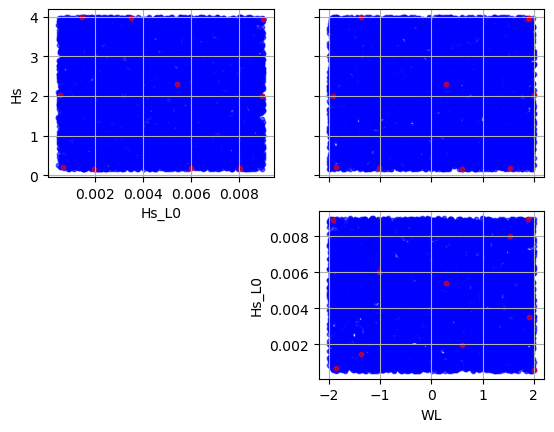

In [3]:
mda_parameters = {"num_centers": 10}
scatter_points_thick = 3

mda = MDA(num_centers=mda_parameters.get("num_centers"))
mda.logger.disabled = True
mda.fit(data=df_dataset, normalize_data=True)
mda.plot_selected_centroids()
plt.show()

mda._exclude_attributes = []
mda.save_model(
    model_path=op.join(export_dir, "mda_model.pkl"),
)

(<Figure size 700x700 with 3 Axes>,
 array([[<Axes: xlabel='Tp', ylabel='Hs'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='WL', ylabel='Tp'>]], dtype=object))

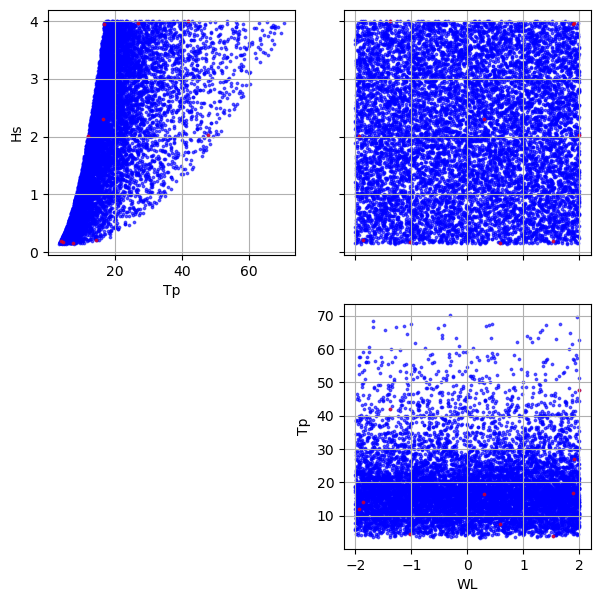

In [4]:
df_centroids = mda.centroids.copy()
df_lhs_data = mda.data.copy()
plot_scatters_Tp(
    df_centroids=df_centroids,
    df_lhs_data=df_lhs_data,
    scatter_points_thick=scatter_points_thick,
)

In [5]:
# Generate infered variable fp to fill the params.txt
# LHS results
df_dataset["fp"] = 1 / np.sqrt(
    (df_dataset.Hs.values * 2 * np.pi) / (9.81 * df_dataset.Hs_L0.values)
)
# MDA results
mda.centroids["fp"] = 1 / np.sqrt(
    (mda.centroids.Hs.values * 2 * np.pi) / (9.81 * mda.centroids.Hs_L0.values)
)
mda.centroids["Tp"] = np.sqrt(
    (mda.centroids.Hs.values * 2 * np.pi) / (9.81 * mda.centroids.Hs_L0.values)
)

## 2. Numerical model XBeach NH

Once the hydrodynamic cases to be numerically simulated have been selected through the MDA algorithm, we proceed to launch these cases in XBeach NH. It is a versatile numerical tool designed to simulate a non-hydrostatic, phase-resolving wave model capable of simulating waves from deep waters to the shoreline, modeling wave breaking, bottom friction, wave- induced setup and runup, and the generation and propagation of infragravity waves.

In [6]:
metamodel_parameters = mda.centroids[["Hs", "Tp", "WL", "fp"]].to_dict(orient="list")
# metamodel_parameters

In [7]:
# Create an instance of the XBEACH model wrapper
xbeach_model = HyXBeachNHProfile(
    templates_dir=templates_dir,
    metamodel_parameters=metamodel_parameters,
    fixed_parameters={},
    output_dir=output_dir,
)

xbeach_model.save_model(model_path=op.join(export_dir, "xbeach_model.pkl"))

2025-08-25 10:22:33,974 - HyXBeachNHProfile - WARNING - Parameter Hs is not in the default_parameters
2025-08-25 10:22:33,975 - HyXBeachNHProfile - WARNING - Parameter Tp is not in the default_parameters
2025-08-25 10:22:33,975 - HyXBeachNHProfile - WARNING - Parameter WL is not in the default_parameters
2025-08-25 10:22:33,976 - HyXBeachNHProfile - WARNING - Parameter fp is not in the default_parameters


### Build, run and postprocess cases

In [8]:
# Build the input files
xbeach_model.build_cases(mode="one_by_one")

In [ ]:
# Uncomment if you want to run online
xbeach_model.run_cases_in_background(launcher="geoocean-cluster", num_workers=10)

Monitor cases

In [9]:
xbeach_model.monitor_cases()

,Case,Status
0,0000,End of run
1,0001,End of run
2,0002,End of run
3,0003,End of run
4,0004,End of run
5,0005,End of run
6,0006,End of run
7,0007,End of run
8,0008,End of run
9,0009,End of run


## 3. Data Postprocessing
The primary output variable generated by XBeach include the time series of water level along the profile. This output serves as crucial indicator of the hydrodynamic processes impacting the reef. From this SWASH output, we compute various other key variables. Different output quantities will be given here to go over the different wave transformation processes including wave propagation, dispersion, flooding and drying, moving shoreline, surf-beat, infragravity waves, set-up induced by wave breaking, run-up and overtopping discharge. 

- To this end, the time-dependent surface elevation is stored at every grid point for every time step. After removing the warmup time from the sea surface series, a FFt is applied to obtain its representation in the frequency domain. A further classification is given by spliting the wave frequency into incident waves IC (0.04 - 1), infragravity waves IG (0.004 - 0.04) and very low frequency VLF (0.001 - 0.004). 

Variables:
- `Hrms`
- `Msetup`
- `Hfreqs` Hs, Hss, Hig, Hvlf
- `Msetup`

In [10]:
# Post-process the output files
# b = xbeach_model.list_available_postprocess_vars()
# ['Msetup', 'Hrms', 'Hfreqs', 'Watlev']
vars_to_postprocess = ["Msetup", "Hrms", "Hfreqs", "Watlev"]

In [11]:
# Example: Post-process the output files for case 0
postprocessed_0 = xbeach_model.postprocess_case(
    case_num=0, case_dir=op.join(output_dir, "0000"), output_vars=vars_to_postprocess
)

# Post-process the output files for all MDA cases
postprocessed_output = xbeach_model.postprocess_cases(
    output_vars=vars_to_postprocess, write_output_nc=True
)
postprocessed_output

2025-08-25 10:22:47,456 - HyXBeachNHProfile - WARNING - Output postprocessed file already exists. Skipping postprocessing.


<xarray.Dataset> Size: 30MB
Dimensions:   (case_num: 10, Xp: 522, Tsec: 701)
Coordinates:
  * Xp        (Xp) float64 4kB 0.218 4.718 9.218 ... 1.238e+03 1.239e+03
  * case_num  (case_num) int64 80B 0 1 2 3 4 5 6 7 8 9
  * Tsec      (Tsec) float64 6kB 0.0 6.0 12.0 ... 4.188e+03 4.194e+03 4.2e+03
Data variables:
    Msetup    (case_num, Xp) float64 42kB ...
    Hrms      (case_num, Xp) float64 42kB ...
    Hs        (case_num, Xp) float64 42kB ...
    Hss       (case_num, Xp) float64 42kB ...
    ig        (case_num, Xp) float64 42kB ...
    Hvlf      (case_num, Xp) float64 42kB ...
    Watlev    (case_num, Tsec, Xp) float64 29MB ...

#### To avoid running again the workflow load the MDA and SWASH models and the postprocessed_output

In [12]:
# Load the MDA model
mda = load_model(op.join(export_dir, "mda_model.pkl"))

# Load the HySwash model
xbeach_model = load_model(op.join(export_dir, "xbeach_model.pkl"))

# Load postprocessed data from NetCDF File in case we do not want to postprocess again
postprocessed_output = xr.open_dataset(op.join(output_dir, "output_postprocessed.nc"))

#### Plot postprocessed output for different cases

Choose the variable (Msetup, Hrms, Hs, Hss, ig, Hvlf) and cases you want to visualize

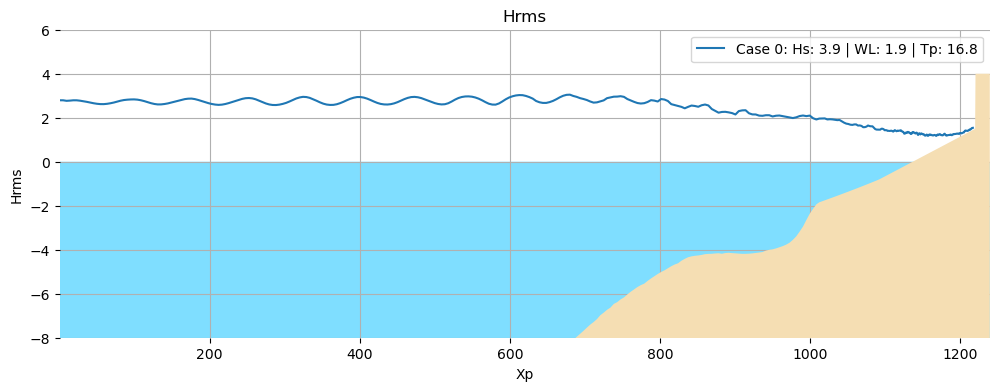

In [13]:
postprocessed_var = "Hrms"
cases = [0]
keys = ["Hs", "Tp", "WL"]

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_depthfile(
    depthfile=op.join(templates_dir, "bed.dep"),
    meshProfilefile=op.join(templates_dir, "x.grd"),
    ax=ax,
)
for case_num in cases:
    # values = df_centroids.iloc[case_num].to_dict()
    values = {
        k: v for k, v in df_centroids.iloc[case_num].to_dict().items() if k in keys
    }
    postprocessed_output.isel(case_num=case_num)[postprocessed_var].plot(
        ax=ax,
        label=f"Case {case_num}: {' | '.join(f'{k}: {v:.1f}' for k, v in values.items())}",
    )
ax.set_ylim(-8, 6)
ax.set_title(postprocessed_var)
ax.legend()
ax.grid(True)

### Total Water Elevation Visualization
Fill case_num with the number of the simulation you want to visualize

In [14]:
case_num = 0

depthfile = op.join(templates_dir, "bed.dep")
depth_array = np.loadtxt(depthfile)[2, :] * -1
data = postprocessed_output[["Watlev"]].isel(case_num=case_num).squeeze()
ani = animate_case_propagation(
    data,
    depth_array,
    tini=0,
    tend=200,
    tstep=2,
    figsize=(11, 3),
)

HTML(ani.to_jshtml())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>
